# Final model comparison and error analysis

This notebook compares the selected LightGBM baseline with SchNet, tests whether their errors are complementary, and evaluates a validation-selected weighted ensemble. It reuses saved metrics, predictions, checkpoints, and deterministic feature caches; no new architecture is introduced.

## Notebook contract

**Goal:** consolidate the validated model comparison and assess ensemble complementarity.  
**Inputs:** saved classical/SchNet metrics, checkpoints, feature cache, and prediction artifacts.  
**Outputs:** final metrics, aligned random/scaffold predictions, presentation figures, and conclusions.  
**Main questions:** Which approach is best for interpolation, unseen scaffolds, and final delivery?


## 1. Setup and exact split reproduction

In [15]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "src").is_dir():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))


In [16]:
# Standard library
import json

# Third-party
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from sklearn.metrics import mean_absolute_error

# Project
from src.analysis import build_prediction_frame, difficult_tables, error_associations
from src.config import (
    CLASSICAL_ANALYSIS_FEATURES, CLASSICAL_METRICS, CLASSICAL_RANDOM_PREDICTIONS,
    CLASSICAL_SCAFFOLD_PREDICTIONS, DATA_PATH, FINAL_FIGURE_DIR,
    FINAL_RANDOM_PREDICTIONS, FINAL_SCAFFOLD_PREDICTIONS,
    FINAL_VALIDATION_PREDICTIONS, PROJECT_ROOT, RANDOM_SEED, RESULTS_DIR,
    SCHNET_METRICS, SCHNET_RANDOM_PREDICTIONS, SCHNET_SCAFFOLD_PREDICTIONS,
    SPLIT_ARTIFACT,
)
from src.data import (
    labeled_molecules, load_dataset, load_required_csv, load_required_numpy,
    validate_analysis_features, validate_prediction_alignment, validate_prediction_split,
    validate_split_indices,
)
from src.evaluation import metric_row
from src.plotting import MODEL_COLORS, configure_matplotlib, save_figure


In [17]:
ROOT = PROJECT_ROOT
FIGURE_DIR = FINAL_FIGURE_DIR
RANDOM_STATE = RANDOM_SEED
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
configure_matplotlib()

df = load_dataset(DATA_PATH)
labeled = labeled_molecules(df)
y = labeled["gap"].to_numpy(dtype=np.float32)
split_data = load_required_numpy(SPLIT_ARTIFACT, "notebooks/02_classical_baselines.ipynb")
random_train_idx, random_val_idx, random_test_idx = (
    split_data["random_train"], split_data["random_validation"], split_data["random_test"])
scaffold_train_idx, scaffold_val_idx, scaffold_test_idx = (
    split_data["scaffold_train"], split_data["scaffold_validation"], split_data["scaffold_test"])
validate_split_indices(random_train_idx, random_val_idx, random_test_idx, len(labeled))
validate_split_indices(scaffold_train_idx, scaffold_val_idx, scaffold_test_idx, len(labeled))


## 2. Load and validate saved predictions

Notebook 02 supplies classical validation/test predictions and notebook 03 supplies SchNet validation/test predictions. Missing inputs raise an actionable error; this notebook never constructs or trains either model.


In [18]:
classical_random = load_required_csv(
    CLASSICAL_RANDOM_PREDICTIONS, "notebooks/02_classical_baselines.ipynb")
classical_scaffold = load_required_csv(
    CLASSICAL_SCAFFOLD_PREDICTIONS, "notebooks/02_classical_baselines.ipynb")
schnet_random = load_required_csv(
    SCHNET_RANDOM_PREDICTIONS, "notebooks/03_schnet.ipynb")
schnet_scaffold = load_required_csv(
    SCHNET_SCAFFOLD_PREDICTIONS, "notebooks/03_schnet.ipynb")

for frame in (classical_random, classical_scaffold, schnet_random, schnet_scaffold):
    validate_prediction_alignment(frame, labeled)
for frame, indices, split in [
    (classical_random.query("split == 'random_validation'"), random_val_idx, "random_validation"),
    (classical_random.query("split == 'random_test'"), random_test_idx, "random_test"),
    (classical_scaffold.query("split == 'scaffold_validation'"), scaffold_val_idx, "scaffold_validation"),
    (classical_scaffold.query("split == 'scaffold_test'"), scaffold_test_idx, "scaffold_test"),
]:
    validate_prediction_split(frame, indices, split=split)


### 2.2 Align model predictions and load molecular metadata


In [19]:
random_validation = classical_random.query("split == 'random_validation'").reset_index(drop=True)
scaffold_validation = classical_scaffold.query("split == 'scaffold_validation'").reset_index(drop=True)
random_test = classical_random.query("split == 'random_test'").reset_index(drop=True)
scaffold_test = classical_scaffold.query("split == 'scaffold_test'").reset_index(drop=True)
random_schnet_validation = schnet_random.query("split == 'random_validation'").reset_index(drop=True)
scaffold_schnet_validation = schnet_scaffold.query("split == 'scaffold_validation'").reset_index(drop=True)
random_schnet_test = schnet_random.query("split == 'random_test'").reset_index(drop=True)
scaffold_schnet_test = schnet_scaffold.query("split == 'scaffold_test'").reset_index(drop=True)
for classical, schnet in [(random_validation, random_schnet_validation),
                          (scaffold_validation, scaffold_schnet_validation),
                          (random_test, random_schnet_test), (scaffold_test, scaffold_schnet_test)]:
    np.testing.assert_array_equal(classical["mol_id"], schnet["mol_id"])
    np.testing.assert_allclose(classical["target"], schnet["target"], rtol=0, atol=0)

random_val_true, random_lgbm_val = random_validation["target"].to_numpy(), random_validation["prediction"].to_numpy()
random_schnet_val = random_schnet_validation["prediction"].to_numpy()
scaffold_val_true, scaffold_lgbm_val = scaffold_validation["target"].to_numpy(), scaffold_validation["prediction"].to_numpy()
scaffold_schnet_val = scaffold_schnet_validation["prediction"].to_numpy()
random_test_true, random_lgbm_test = random_test["target"].to_numpy(), random_test["prediction"].to_numpy()
random_schnet_test = random_schnet_test["prediction"].to_numpy()
scaffold_test_true, scaffold_lgbm_test = scaffold_test["target"].to_numpy(), scaffold_test["prediction"].to_numpy()
scaffold_schnet_test = scaffold_schnet_test["prediction"].to_numpy()

analysis_features = load_required_numpy(
    CLASSICAL_ANALYSIS_FEATURES, "notebooks/02_classical_baselines.ipynb")
validate_analysis_features(analysis_features, labeled)
X_size = analysis_features["X_size"]
X_geometry = analysis_features["X_geometry"]
scaffolds = analysis_features["scaffolds"]
classical_metrics = load_required_csv(CLASSICAL_METRICS, "notebooks/02_classical_baselines.ipynb")
best_classical_random = classical_metrics.query("split_strategy == 'random'").sort_values("validation_mae").iloc[0]
classical_family = best_classical_random["model"]
print("Loaded and aligned classical and SchNet artifacts; no model reconstruction performed.")


Loaded and aligned classical and SchNet artifacts; no model reconstruction performed.


## 3. Consolidated model results

In [20]:
schnet_metrics = load_required_csv(SCHNET_METRICS, "notebooks/03_schnet.ipynb")
base_rows = schnet_metrics.copy()
base_rows["absolute_test_mae_difference_vs_lightgbm"] = np.nan
base_rows["relative_test_mae_difference_vs_lightgbm_pct"] = np.nan
for split_name in ["random", "scaffold"]:
    reference = base_rows[(base_rows["split"] == split_name) & base_rows["model"].str.contains("LightGBM")]["test_mae"].iloc[0]
    mask = base_rows["split"].eq(split_name)
    base_rows.loc[mask, "absolute_test_mae_difference_vs_lightgbm"] = base_rows.loc[mask, "test_mae"] - reference
    base_rows.loc[mask, "relative_test_mae_difference_vs_lightgbm_pct"] = (
        100 * (base_rows.loc[mask, "test_mae"] - reference) / reference
    )
display(base_rows)

wide_summary = base_rows.pivot(index="split", columns="model", values="test_mae")
wide_summary["schnet_minus_lightgbm_absolute"] = (
    wide_summary["SchNet"] - wide_summary[classical_family]
)
wide_summary["schnet_minus_lightgbm_relative_pct"] = (
    100 * wide_summary["schnet_minus_lightgbm_absolute"] / wide_summary[classical_family]
)
display(wide_summary)

,split,model,validation_mae,test_mae,test_rmse,test_r2,training_time_seconds,trainable_parameters,absolute_test_mae_difference_vs_lightgbm,relative_test_mae_difference_vs_lightgbm_pct
0,random,SchNet,0.014243,0.014572,0.366911,0.019825,356.445986,13793.0,0.000311,2.182114
1,random,Morgan + RDKit 2D + simple 3D + LightGBM,0.013886,0.014261,0.367294,0.017775,106.245370,NaN,0.000000,0.000000
2,scaffold,SchNet,0.013148,0.019954,0.514755,0.012527,331.613799,13793.0,-0.001866,-8.553538
3,scaffold,Morgan + RDKit 2D + simple 3D + LightGBM,0.014583,0.021821,0.515300,0.010435,66.518367,NaN,0.000000,0.000000


model,Morgan + RDKit 2D + simple 3D + LightGBM,SchNet,schnet_minus_lightgbm_absolute,schnet_minus_lightgbm_relative_pct
split,,,,
random,0.014261,0.014572,0.000311,2.182114
scaffold,0.021821,0.019954,-0.001866,-8.553538


## 4. Comparative per-molecule error data

In [21]:
SIZE_NAMES = [
    "n_atoms", "n_heavy_atoms", "n_bonds", "n_atom_types",
    "element_H", "element_C", "element_N", "element_O", "element_F",
    "bond_type_1", "bond_type_1.5", "bond_type_2", "bond_type_3",
]
GEOMETRY_NAMES = [
    "radius_of_gyration", "mean_bond_length", "std_bond_length",
    "max_atomic_distance", "coordinate_cov_eigenvalue_1",
    "coordinate_cov_eigenvalue_2", "coordinate_cov_eigenvalue_3",
]


random_predictions = build_prediction_frame(
    split="random", train_indices=random_train_idx, test_indices=random_test_idx,
    targets=random_test_true, lightgbm_predictions=random_lgbm_test,
    schnet_predictions=random_schnet_test, molecule_table=labeled, scaffolds=scaffolds,
    size_matrix=X_size, size_names=SIZE_NAMES,
    geometry_matrix=X_geometry, geometry_names=GEOMETRY_NAMES,
)
scaffold_predictions = build_prediction_frame(
    split="scaffold", train_indices=scaffold_train_idx, test_indices=scaffold_test_idx,
    targets=scaffold_test_true, lightgbm_predictions=scaffold_lgbm_test,
    schnet_predictions=scaffold_schnet_test, molecule_table=labeled, scaffolds=scaffolds,
    size_matrix=X_size, size_names=SIZE_NAMES,
    geometry_matrix=X_geometry, geometry_names=GEOMETRY_NAMES,
)

random_predictions.to_csv(RESULTS_DIR / "final_predictions_random_test.csv", index=False)
scaffold_predictions.to_csv(RESULTS_DIR / "final_predictions_scaffold_test.csv", index=False)



display(Markdown("**Random-test error associations**"))
display(error_associations(random_predictions, GEOMETRY_NAMES))
display(Markdown("**Scaffold-test error associations**"))
display(error_associations(scaffold_predictions, GEOMETRY_NAMES))

element_rows = []
for split_name, frame in [("random", random_predictions), ("scaffold", scaffold_predictions)]:
    for element in ["C", "N", "O", "F"]:
        present = frame[f"element_{element}"] > 0
        element_rows.append({
            "split": split_name, "element": element,
            "molecules_with_element": int(present.sum()),
            "mean_schnet_improvement": frame.loc[present, "schnet_improvement"].mean(),
            "median_schnet_improvement": frame.loc[present, "schnet_improvement"].median(),
        })
element_analysis = pd.DataFrame(element_rows)
display(Markdown("**Element-composition summary (positive favors SchNet)**"))
display(element_analysis)

**Random-test error associations**

,lightgbm_error_spearman,schnet_error_spearman,schnet_improvement_spearman
target,-0.085437,-0.106662,0.002255
n_atoms,-0.185608,-0.105730,-0.068192
n_heavy_atoms,0.027794,-0.013821,0.036184
scaffold_train_frequency,-0.047112,0.005378,-0.038134
radius_of_gyration,-0.077067,-0.036389,-0.025835
mean_bond_length,0.057017,0.012902,0.024803
std_bond_length,-0.098678,-0.074176,-0.036679
max_atomic_distance,-0.060035,-0.034884,-0.011257
coordinate_cov_eigenvalue_1,-0.132870,-0.095080,-0.044502
coordinate_cov_eigenvalue_2,-0.014558,-0.019652,0.004527


**Scaffold-test error associations**

,lightgbm_error_spearman,schnet_error_spearman,schnet_improvement_spearman
target,-0.068576,0.001784,-0.124325
n_atoms,-0.102549,-0.030718,-0.073587
n_heavy_atoms,0.015511,0.053020,-0.017412
scaffold_train_frequency,NaN,NaN,NaN
radius_of_gyration,-0.083107,-0.016474,-0.057271
mean_bond_length,0.175626,0.088241,0.110349
std_bond_length,0.024427,-0.013209,0.048796
max_atomic_distance,-0.065474,-0.012388,-0.044725
coordinate_cov_eigenvalue_1,-0.038844,-0.040678,-0.009342
coordinate_cov_eigenvalue_2,-0.048026,0.016808,-0.053930


**Element-composition summary (positive favors SchNet)**

,split,element,molecules_with_element,mean_schnet_improvement,median_schnet_improvement
0,random,C,8571,-0.000311,-0.000637
1,random,N,5253,0.000445,-0.000200
2,random,O,7275,-0.000501,-0.000642
3,random,F,147,0.002793,0.001147
4,scaffold,C,8571,0.001866,0.000362
5,scaffold,N,5327,0.001964,0.000524
6,scaffold,O,7293,0.001069,0.000016
7,scaffold,F,3,0.012312,0.001486


## 5. Difficult molecules

In [22]:

for split_name, frame in [("random", random_predictions), ("scaffold", scaffold_predictions)]:
    display(Markdown(f"### {split_name.title()} test"))
    for title, table in difficult_tables(frame).items():
        display(Markdown(f"**{title}**"))
        display(table)

display(Markdown(
    "These rankings identify candidates for chemical review; they do not establish a causal "
    "relationship between a substructure and model performance."
))

### Random test

**Both models predict poorly**

,mol_id,target,lightgbm_prediction,schnet_prediction,lightgbm_absolute_error,schnet_absolute_error,scaffold_train_frequency,n_atoms,n_heavy_atoms,smiles
6589,79512,34.2900,0.313908,0.346879,33.976092,33.943121,0,21.0,9.0,[C@@H3][C@@]12[C@H2][C@@]([C@@H3])([C@H2]1)[C@...
7649,109643,0.1494,0.233937,0.246603,0.084537,0.097203,0,14.0,9.0,O[C@@]12[C@@H]3[C@H]4O[C@@H]3[NH2+][C@@H]1[C@H]42
7995,106077,0.1547,0.233542,0.247382,0.078842,0.092682,0,13.0,8.0,[NH2+]1[C@H]2[C@@H]3[C@H]2[C@@H]2O[C@H]1[C@@H]23
5984,43658,0.1550,0.232752,0.246061,0.077752,0.091061,0,16.0,9.0,[C@@H3][C@@]12[NH2+][C@@H]3O[C@H]4[C@@H]3[C@@H...
305,51019,0.1549,0.230754,0.235912,0.075854,0.081012,0,17.0,9.0,[C@@H3][C@@]12[C@@H]3[C@H]4[C@@H2][NH2+][C@@H]...
884,23280,0.1738,0.324288,0.248554,0.150488,0.074754,0,18.0,8.0,[C@@H3][C@@H]1[C@H2][C@@H]2[C@@H]3[C@H2][C@H]1...
2670,95176,0.1521,0.238753,0.224622,0.086653,0.072522,0,14.0,8.0,N[C@]12[C@@H]3[NH2+][C@H2][C@H]1[C@H]2O3
5507,69005,0.1694,0.312986,0.240623,0.143586,0.071223,1,19.0,9.0,[C@@H3][C@@H]1[C@H2][C@@H]2[C@@H]3[C@H2][C@H]1...
3054,20760,0.1587,0.242257,0.226374,0.083557,0.067674,2,17.0,9.0,[C@@H3]O[C@]12[C@@H]3N[C@H]1[NH2+][C@@H2][C@@H]32
3439,93750,0.1155,0.191037,0.180338,0.075537,0.064838,0,13.0,9.0,c1[cH+]oc2c[nH]cc2n1


**Strongly improved by SchNet**

,mol_id,target,lightgbm_prediction,schnet_prediction,lightgbm_absolute_error,schnet_absolute_error,scaffold_train_frequency,n_atoms,n_heavy_atoms,smiles
1460,115101,0.1132,0.211243,0.128375,0.098043,0.015175,328,17.0,9.0,Nc1c(O)coc1[C@H2][N@@H3+]
6738,3852,0.2140,0.299801,0.219465,0.085801,0.005465,323,19.0,9.0,[C@@H3]CC#CC[C@H]1[C@H2][C@H]1[C@@H3]
884,23280,0.1738,0.324288,0.248554,0.150488,0.074754,0,18.0,8.0,[C@@H3][C@@H]1[C@H2][C@@H]2[C@@H]3[C@H2][C@H]1...
5220,3971,0.2021,0.300485,0.225190,0.098385,0.023090,0,20.0,9.0,[C@@H3][C@@H]1[C@H2][C@@H]2[C@@H2][N@@H+]3[C@H...
5507,69005,0.1694,0.312986,0.240623,0.143586,0.071223,1,19.0,9.0,[C@@H3][C@@H]1[C@H2][C@@H]2[C@@H]3[C@H2][C@H]1...
3408,52402,0.1706,0.237981,0.168558,0.067381,0.002042,0,15.0,9.0,[C@@H3][NH2+]C1NN=NC([NH-])N1
3961,25845,0.1675,0.234492,0.172182,0.066992,0.004682,0,14.0,9.0,c1nnnnc1[C@H]1[C@@H2]N1
1076,591,0.1852,0.272285,0.212080,0.087085,0.026880,0,16.0,9.0,[C@@H2]1[C@@H2][C@H]2NNN3[C@H2][C@@H]1[C@@H]23
3353,96990,0.1512,0.212455,0.145427,0.061255,0.005773,0,11.0,9.0,c1cc2c([nH]1)=NONN=2
3746,7498,0.1616,0.237419,0.182892,0.075819,0.021292,0,17.0,9.0,[C@@H3][C@@H2][CH+]1[CH+]N=C([NH-])O[CH+]1


...

**Strongly improved by SchNet**

,mol_id,target,lightgbm_prediction,schnet_prediction,lightgbm_absolute_error,schnet_absolute_error,scaffold_train_frequency,n_atoms,n_heavy_atoms,smiles
3550,76213,0.1662,0.255292,0.165168,0.089092,0.001032,0,16.0,9.0,[C@@H3][C@H2][CH+]1[CH+]N=NOC1[NH-]
6812,115668,0.2041,0.316000,0.228773,0.111900,0.024673,0,19.0,9.0,[C@H2]1[C@H2][C@@H]2O[C@@H]3[C@@H2][C@H2][C@H]...
4595,105003,0.2035,0.315768,0.228758,0.112268,0.025258,0,19.0,9.0,[C@@H2]1[C@@H2][C@H]2[C@H2]O[C@H]3[C@H2][C@@H]...
7938,101029,0.1502,0.233385,0.153582,0.083185,0.003382,0,17.0,9.0,c1ccncc[nH]cc1
7687,55737,0.1476,0.225652,0.151947,0.078052,0.004347,0,16.0,9.0,c1c[nH]ccncnc1
7505,105132,0.1798,0.276762,0.205453,0.096962,0.025653,0,18.0,9.0,[CH-]1[C@@H]2[C@H2][N@H+]3[C@@H]2[C@@H]2[C@H]3...
8003,72662,0.1508,0.226185,0.157408,0.075385,0.006608,0,16.0,9.0,c1cncc[nH]ccn1
7463,1732,0.1939,0.276045,0.207665,0.082145,0.013765,0,18.0,9.0,[CH-]1[C@@H2][C@H2][N@H+]2[C@@H]3[C@H]4[C@@H]3...
8412,94759,0.1666,0.241337,0.173752,0.074737,0.007152,0,13.0,9.0,c1nnnnc1[C@H]1[C@@H2]O1
7551,80493,0.1787,0.283766,0.217210,0.105066,0.038510,0,17.0,9.0,O[C@@H]1[C@@H]2[CH-][C@H]3[C@@H]4[C@H]3[C@H]1[...


**Strongly improved by LightGBM**

,mol_id,target,lightgbm_prediction,schnet_prediction,lightgbm_absolute_error,schnet_absolute_error,scaffold_train_frequency,n_atoms,n_heavy_atoms,smiles
3538,105687,0.2083,0.195417,0.126488,0.012883,0.081812,0,8.0,8.0,O=c1onnoc1=O
2277,44960,0.2398,0.238389,0.192367,0.001411,0.047433,0,13.0,9.0,[NH-][C@H]1O[C@H]2[C@H]3C(=O)N1[C@@H]23
7908,67320,0.2318,0.221860,0.176790,0.009940,0.055010,0,18.0,9.0,c1ccc([C@H]2[C@@H2]N2)cc1
810,104966,0.2228,0.226153,0.271078,0.003353,0.048278,0,15.0,9.0,O=C[C@H]1[C@@H2][C@H2]OC(=O)O1
2885,35454,0.1899,0.190062,0.147344,0.000162,0.042556,0,19.0,9.0,O=C1[C@H2][C@H2][C@H2][C@@H2][C@@H2]C1=O
2778,237,0.2072,0.204635,0.162930,0.002565,0.044270,0,16.0,9.0,O=C[C@H2][N@@H+]1[C@@H]2C(=O)[C@H2][C@@H]21
115,79229,0.1953,0.200116,0.149325,0.004816,0.045975,0,16.0,9.0,O=CC1[N@@H2+][C@H]2[C@H2][C@H]2C1=O
114,104594,0.1934,0.198146,0.148016,0.004746,0.045384,0,15.0,8.0,O=CC1[N@@H2+][C@@H2][C@H2]C1=O
7910,90681,0.2316,0.221057,0.180860,0.010543,0.050740,0,17.0,9.0,c1ccc([C@H]2[C@@H2]O2)cc1
3201,53241,0.2474,0.233500,0.195376,0.013900,0.052024,0,15.0,9.0,O=C1[C@H]2O[C@@H]1[C@@H]1[C@@H2][C@H]2O1


These rankings identify candidates for chemical review; they do not establish a causal relationship between a substructure and model performance.

## 6. Residual complementarity and validation-selected ensemble

In [23]:
random_lgbm_val_residual = random_val_true - random_lgbm_val
random_schnet_val_residual = random_val_true - random_schnet_val
random_test_lgbm_residual = random_test_true - random_lgbm_test
random_test_schnet_residual = random_test_true - random_schnet_test
scaffold_test_lgbm_residual = scaffold_test_true - scaffold_lgbm_test
scaffold_test_schnet_residual = scaffold_test_true - scaffold_schnet_test

residual_correlations = pd.DataFrame([
    {"subset": "random validation", "pearson": np.corrcoef(random_lgbm_val_residual, random_schnet_val_residual)[0,1],
     "spearman": pd.Series(random_lgbm_val_residual).corr(pd.Series(random_schnet_val_residual), method="spearman")},
    {"subset": "random test", "pearson": np.corrcoef(random_test_lgbm_residual, random_test_schnet_residual)[0,1],
     "spearman": pd.Series(random_test_lgbm_residual).corr(pd.Series(random_test_schnet_residual), method="spearman")},
    {"subset": "scaffold test", "pearson": np.corrcoef(scaffold_test_lgbm_residual, scaffold_test_schnet_residual)[0,1],
     "spearman": pd.Series(scaffold_test_lgbm_residual).corr(pd.Series(scaffold_test_schnet_residual), method="spearman")},
])
display(residual_correlations)

weights = np.linspace(0, 1, 101)
validation_curve = pd.DataFrame({
    "schnet_weight": weights,
    "validation_mae": [
        mean_absolute_error(
            random_val_true, weight * random_schnet_val + (1 - weight) * random_lgbm_val
        )
        for weight in weights
    ],
})
best_weight = float(validation_curve.loc[validation_curve["validation_mae"].idxmin(), "schnet_weight"])
print(f"Validation-selected SchNet weight: {best_weight:.2f}")

random_ensemble = best_weight * random_schnet_test + (1 - best_weight) * random_lgbm_test
scaffold_ensemble = best_weight * scaffold_schnet_test + (1 - best_weight) * scaffold_lgbm_test
random_predictions["ensemble_prediction"] = random_ensemble
random_predictions["ensemble_absolute_error"] = np.abs(random_test_true - random_ensemble)
scaffold_predictions["ensemble_prediction"] = scaffold_ensemble
scaffold_predictions["ensemble_absolute_error"] = np.abs(scaffold_test_true - scaffold_ensemble)
random_predictions.to_csv(RESULTS_DIR / "final_predictions_random_test.csv", index=False)
scaffold_predictions.to_csv(RESULTS_DIR / "final_predictions_scaffold_test.csv", index=False)


ensemble_rows = [
    metric_row("random", f"Ensemble (w={best_weight:.2f})", random_test_true, random_ensemble,
               validation_curve["validation_mae"].min()),
    metric_row("scaffold", f"Ensemble (w={best_weight:.2f})", scaffold_test_true, scaffold_ensemble,
               mean_absolute_error(scaffold_val_true,
                   best_weight * scaffold_schnet_val + (1-best_weight) * scaffold_lgbm_val)),
]
final_comparison = pd.concat([base_rows.drop(columns=[
    "absolute_test_mae_difference_vs_lightgbm",
    "relative_test_mae_difference_vs_lightgbm_pct",
]), pd.DataFrame(ensemble_rows)], ignore_index=True)
final_comparison["absolute_test_mae_difference_vs_lightgbm"] = np.nan
final_comparison["relative_test_mae_difference_vs_lightgbm_pct"] = np.nan
for split_name in ["random", "scaffold"]:
    reference = final_comparison[
        (final_comparison["split"] == split_name)
        & final_comparison["model"].str.contains("LightGBM")
    ]["test_mae"].iloc[0]
    mask = final_comparison["split"].eq(split_name)
    final_comparison.loc[mask, "absolute_test_mae_difference_vs_lightgbm"] = (
        final_comparison.loc[mask, "test_mae"] - reference
    )
    final_comparison.loc[mask, "relative_test_mae_difference_vs_lightgbm_pct"] = (
        100 * final_comparison.loc[mask, "absolute_test_mae_difference_vs_lightgbm"] / reference
    )
final_comparison.to_csv(RESULTS_DIR / "final_model_comparison.csv", index=False)
display(final_comparison.sort_values(["split", "test_mae"]))

,subset,pearson,spearman
0,random validation,0.998980,0.502571
1,random test,0.999243,0.495514
2,scaffold test,0.999532,0.572512


Validation-selected SchNet weight: 0.46


,split,model,validation_mae,test_mae,test_rmse,test_r2,training_time_seconds,trainable_parameters,absolute_test_mae_difference_vs_lightgbm,relative_test_mae_difference_vs_lightgbm_pct
4,random,Ensemble (w=0.46),0.012793,0.013131,0.367049,0.019087,NaN,NaN,-0.001129,-7.918799
1,random,Morgan + RDKit 2D + simple 3D + LightGBM,0.013886,0.014261,0.367294,0.017775,106.245370,NaN,0.000000,0.000000
0,random,SchNet,0.014243,0.014572,0.366911,0.019825,356.445986,13793.0,0.000311,2.182114
5,scaffold,Ensemble (w=0.46),0.012724,0.019681,0.514985,0.011643,NaN,NaN,-0.002139,-9.804618
2,scaffold,SchNet,0.013148,0.019954,0.514755,0.012527,331.613799,13793.0,-0.001866,-8.553538
3,scaffold,Morgan + RDKit 2D + simple 3D + LightGBM,0.014583,0.021821,0.515300,0.010435,66.518367,NaN,0.000000,0.000000


## 7. Presentation-ready figures

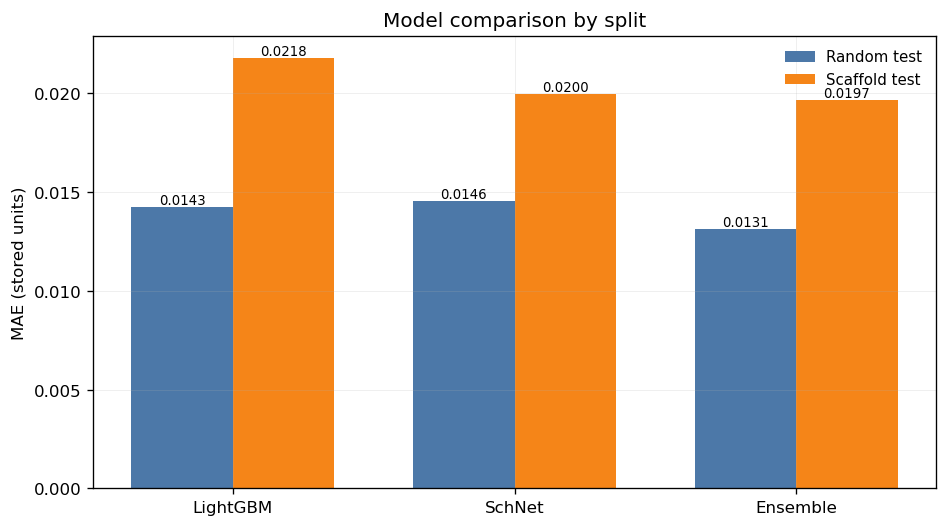

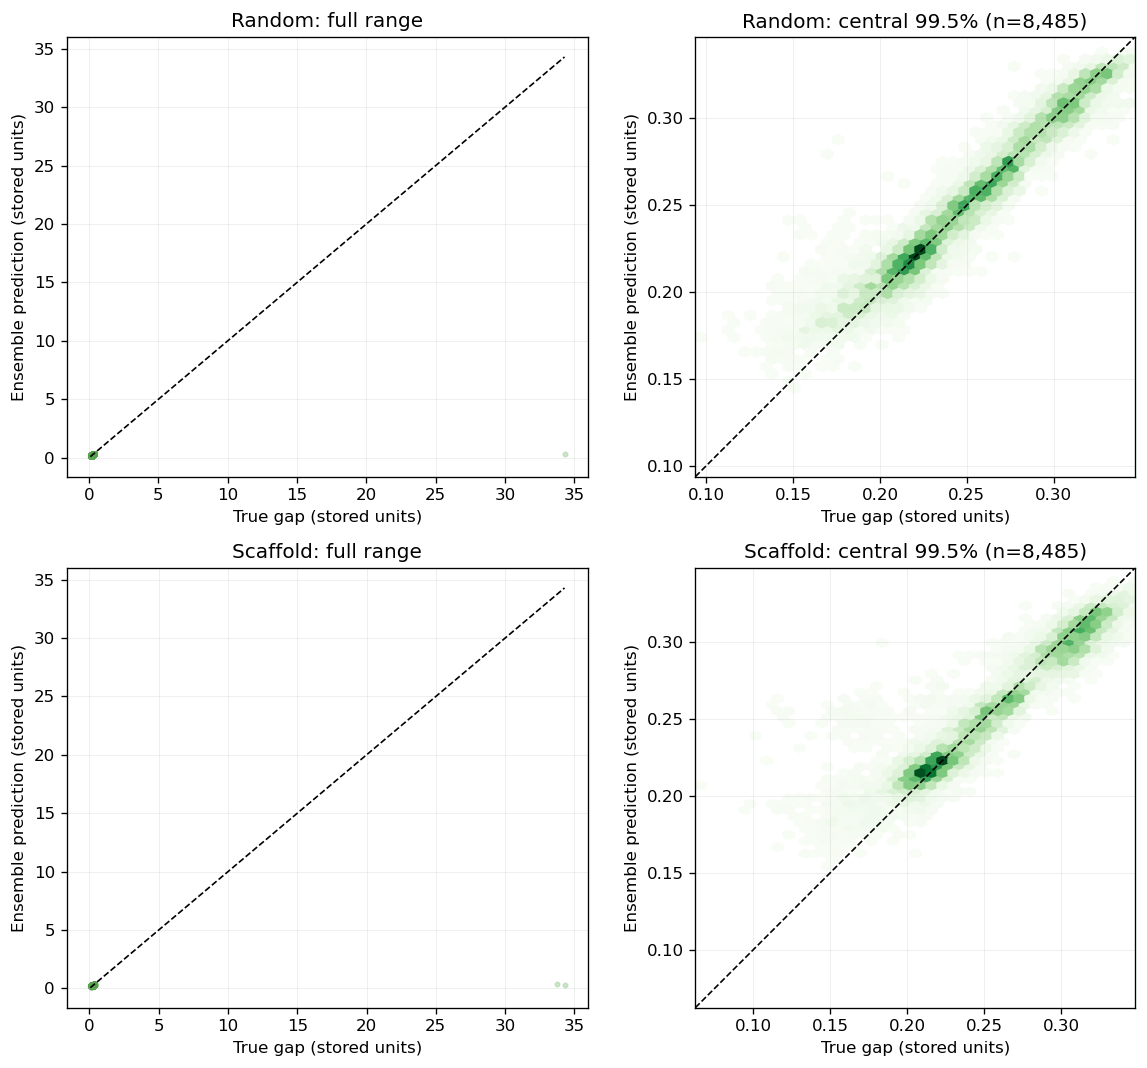

Each split retains a full-range panel. The paired density panel uses the split-specific 99.5th-percentile display limit only; ensemble metrics remain full-sample.

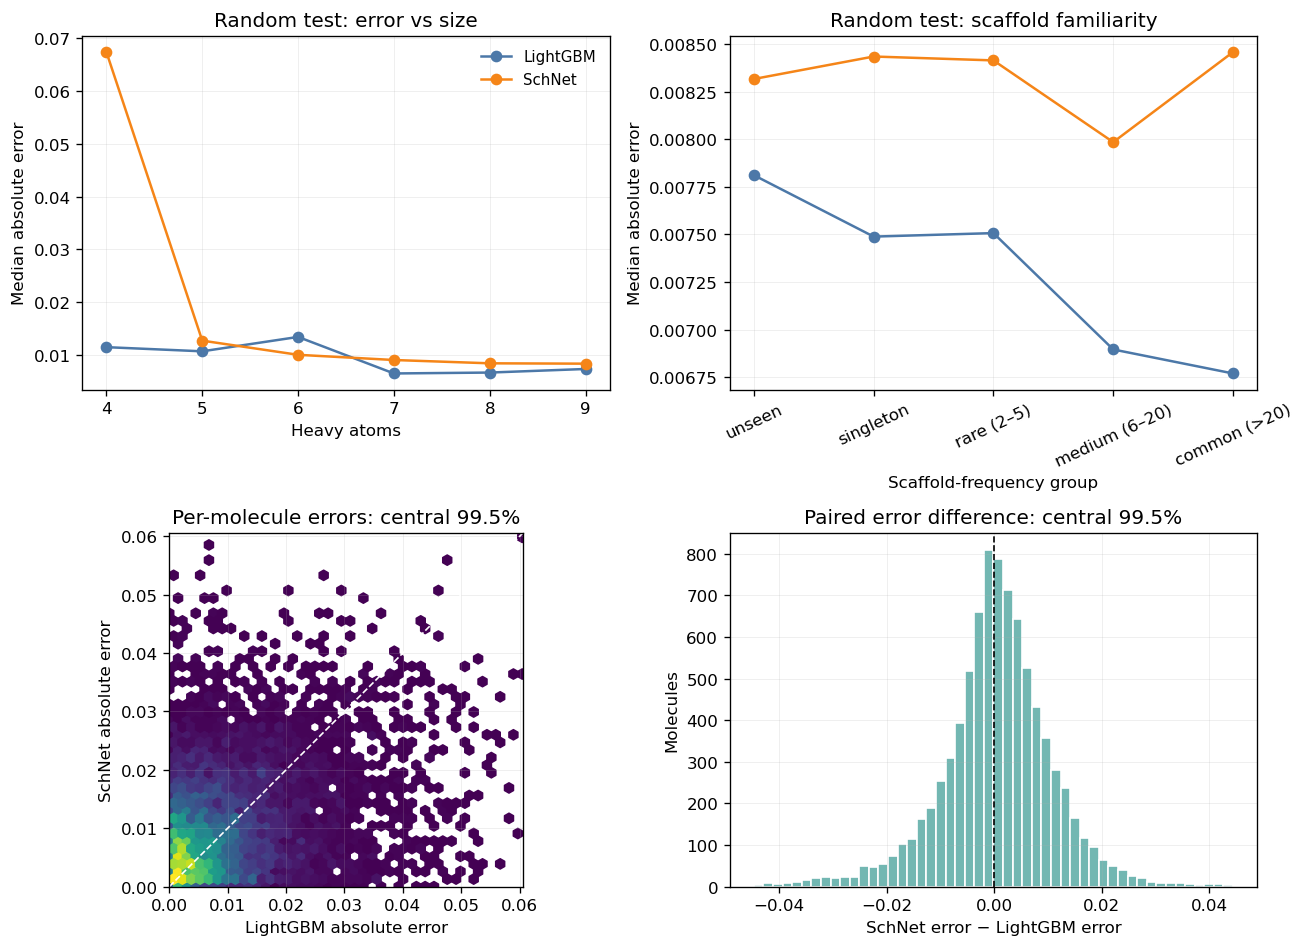

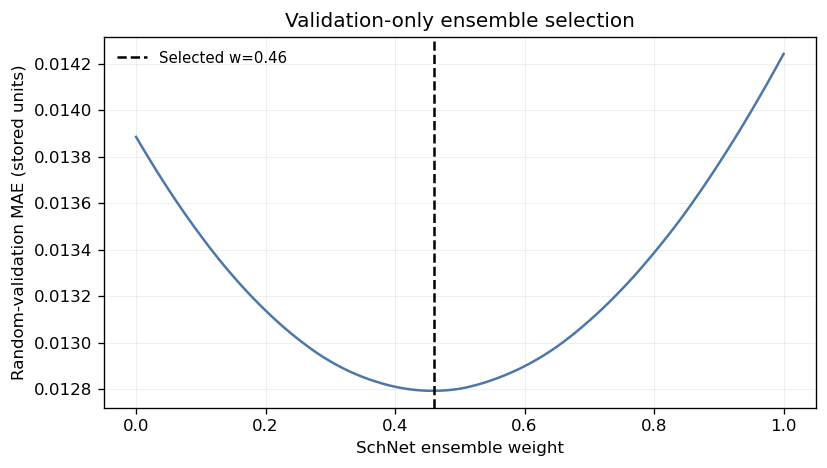

MAE comparisons and ensemble selection remain on linear axes. Density and paired-difference panels use 99.5% visual limits only; all reported metrics use complete test sets.

In [24]:
fig, ax = plt.subplots(figsize=(8, 4.5))
plot_rows = final_comparison.copy()
plot_rows["display_model"] = np.select([plot_rows["model"].str.contains("LightGBM"), plot_rows["model"].str.contains("Ensemble")], ["LightGBM", "Ensemble"], default="SchNet")
comparison_plot = plot_rows.pivot(index="display_model", columns="split", values="test_mae")
order = ["LightGBM", "SchNet", "Ensemble"]
x = np.arange(len(order)); width = .36
random_vals = comparison_plot.loc[order, "random"].to_numpy()
scaffold_vals = comparison_plot.loc[order, "scaffold"].to_numpy()
ax.bar(x - width/2, random_vals, width, label="Random test", color="#4C78A8")
ax.bar(x + width/2, scaffold_vals, width, label="Scaffold test", color="#F58518")
ax.set_xticks(x, order); ax.set_ylim(bottom=0)
ax.set_ylabel("MAE (stored units)"); ax.set_title("Model comparison by split")
ax.legend(frameon=False)
for xpos, value in zip(x - width/2, random_vals): ax.text(xpos, value, f"{value:.4f}", ha="center", va="bottom", fontsize=8)
for xpos, value in zip(x + width/2, scaffold_vals): ax.text(xpos, value, f"{value:.4f}", ha="center", va="bottom", fontsize=8)
save_figure("01_model_comparison_mae", FIGURE_DIR)

fig, axes = plt.subplots(2, 2, figsize=(10, 9))
for row, (split_name, frame) in enumerate([("Random", random_predictions), ("Scaffold", scaffold_predictions)]):
    target = frame["target"].to_numpy()
    prediction = frame["ensemble_prediction"].to_numpy()
    full_limits = [min(target.min(), prediction.min()), max(target.max(), prediction.max())]
    axes[row, 0].scatter(target, prediction, s=7, alpha=.25, color=MODEL_COLORS["Ensemble"], rasterized=True)
    axes[row, 0].plot(full_limits, full_limits, "--", color="black", linewidth=1)
    axes[row, 0].set(xlabel="True gap (stored units)", ylabel="Ensemble prediction (stored units)",
                     title=f"{split_name}: full range")
    limit = np.quantile(np.r_[target, prediction], .995)
    mask = (target <= limit) & (prediction <= limit)
    zoom_limits = [min(target[mask].min(), prediction[mask].min()), limit]
    axes[row, 1].hexbin(target[mask], prediction[mask], gridsize=40, mincnt=1, cmap="Greens")
    axes[row, 1].plot(zoom_limits, zoom_limits, "--", color="black", linewidth=1)
    axes[row, 1].set(xlim=zoom_limits, ylim=zoom_limits, aspect="equal",
                     xlabel="True gap (stored units)", ylabel="Ensemble prediction (stored units)",
                     title=f"{split_name}: central 99.5% (n={mask.sum():,})")
save_figure("02_best_final_predicted_vs_true", FIGURE_DIR)
display(Markdown("Each split retains a full-range panel. The paired density panel uses the split-specific 99.5th-percentile display limit only; ensemble metrics remain full-sample."))

fig, axes = plt.subplots(2, 2, figsize=(11, 8))
frame = random_predictions
size_summary = frame.groupby("n_heavy_atoms")[["lightgbm_absolute_error", "schnet_absolute_error"]].median()
axes[0,0].plot(size_summary.index, size_summary["lightgbm_absolute_error"], marker="o", color=MODEL_COLORS["LightGBM"], label="LightGBM")
axes[0,0].plot(size_summary.index, size_summary["schnet_absolute_error"], marker="o", color=MODEL_COLORS["SchNet"], label="SchNet")
axes[0,0].set(xlabel="Heavy atoms", ylabel="Median absolute error", title="Random test: error vs size")
axes[0,0].legend(frameon=False)
frequency_group = pd.cut(frame["scaffold_train_frequency"], bins=[-1, 0, 1, 5, 20, np.inf], labels=["unseen", "singleton", "rare (2–5)", "medium (6–20)", "common (>20)"])
summary = frame.assign(scaffold_frequency_group=frequency_group).groupby("scaffold_frequency_group", observed=True)[["lightgbm_absolute_error", "schnet_absolute_error"]].median()
axes[0,1].plot(summary.index.astype(str), summary["lightgbm_absolute_error"], marker="o", color=MODEL_COLORS["LightGBM"], label="LightGBM")
axes[0,1].plot(summary.index.astype(str), summary["schnet_absolute_error"], marker="o", color=MODEL_COLORS["SchNet"], label="SchNet")
axes[0,1].set(xlabel="Scaffold-frequency group", ylabel="Median absolute error", title="Random test: scaffold familiarity")
axes[0,1].tick_params(axis="x", rotation=25)
limit = np.quantile(np.r_[frame["lightgbm_absolute_error"], frame["schnet_absolute_error"]], .995)
mask = (frame["lightgbm_absolute_error"] <= limit) & (frame["schnet_absolute_error"] <= limit)
axes[1,0].hexbin(frame.loc[mask, "lightgbm_absolute_error"], frame.loc[mask, "schnet_absolute_error"], gridsize=40, mincnt=1, cmap="viridis")
axes[1,0].plot([0, limit], [0, limit], "--", color="white", linewidth=1)
axes[1,0].set(xlim=(0, limit), ylim=(0, limit), aspect="equal", xlabel="LightGBM absolute error",
              ylabel="SchNet absolute error", title="Per-molecule errors: central 99.5%")
difference = frame["schnet_absolute_error"] - frame["lightgbm_absolute_error"]
diff_limit = difference.abs().quantile(.995)
axes[1,1].hist(difference[difference.abs() <= diff_limit], bins=50, color="#72B7B2", edgecolor="white")
axes[1,1].axvline(0, color="black", linestyle="--", linewidth=1)
axes[1,1].set(xlabel="SchNet error − LightGBM error", ylabel="Molecules", title="Paired error difference: central 99.5%")
save_figure("03_comparative_error_analysis", FIGURE_DIR)

plt.figure(figsize=(7, 4))
plt.plot(validation_curve["schnet_weight"], validation_curve["validation_mae"], color="#4C78A8")
plt.axvline(best_weight, color="black", linestyle="--", label=f"Selected w={best_weight:.2f}")
plt.xlabel("SchNet ensemble weight"); plt.ylabel("Random-validation MAE (stored units)")
plt.title("Validation-only ensemble selection"); plt.legend(frameon=False)
save_figure("04_ensemble_weight_validation", FIGURE_DIR)
display(Markdown("MAE comparisons and ensemble selection remain on linear axes. Density and paired-difference panels use 99.5% visual limits only; all reported metrics use complete test sets."))


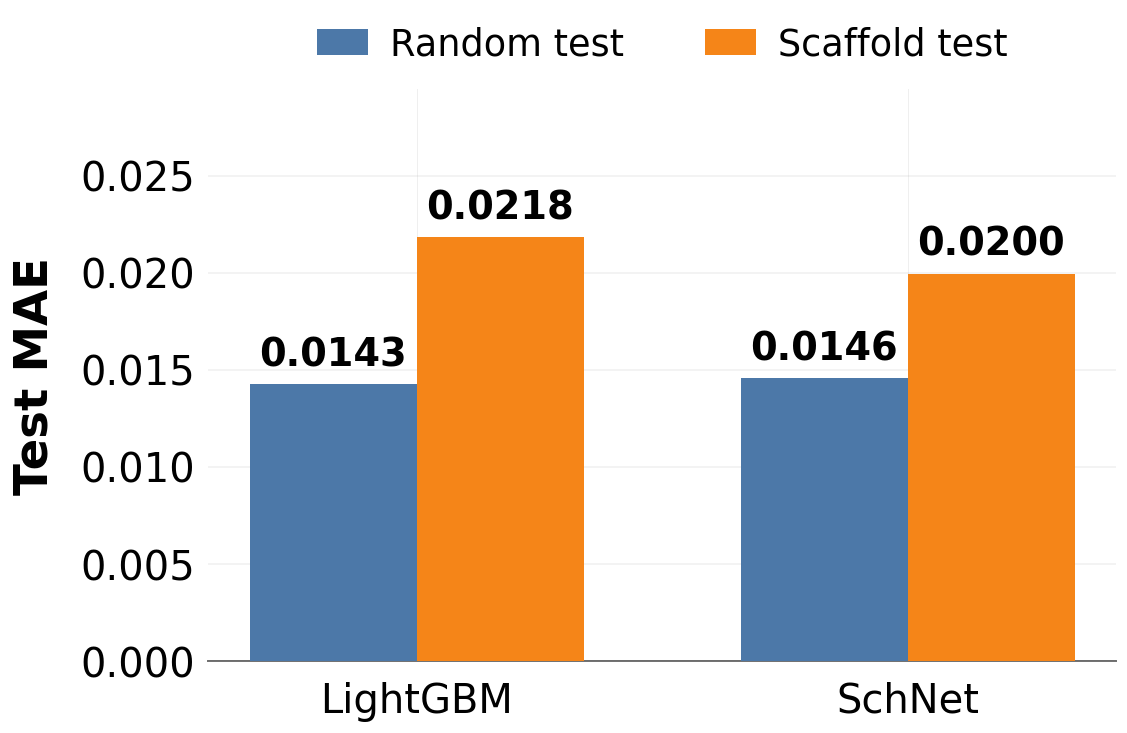

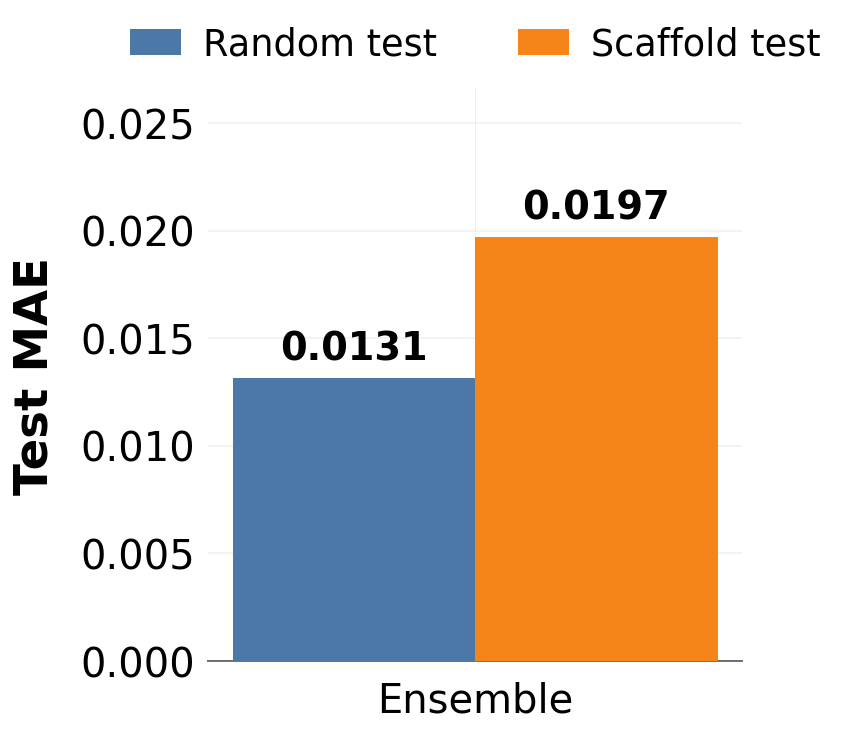

In [26]:
# ============================================================
# Model-comparison figures for presentation
#
# Figure 1: LightGBM vs SchNet
# Figure 2: Ensemble only
# ============================================================

import numpy as np
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# Prepare comparison table
# ------------------------------------------------------------

plot_rows = final_comparison.copy()

plot_rows["display_model"] = np.select(
    [
        plot_rows["model"].str.contains(
            "LightGBM",
            case=False,
            na=False,
        ),
        plot_rows["model"].str.contains(
            "Ensemble",
            case=False,
            na=False,
        ),
    ],
    [
        "LightGBM",
        "Ensemble",
    ],
    default="SchNet",
)

comparison_plot = plot_rows.pivot(
    index="display_model",
    columns="split",
    values="test_mae",
)


# ------------------------------------------------------------
# Display settings
# ------------------------------------------------------------

split_colors = {
    "random": "#4C78A8",
    "scaffold": "#F58518",
}

FONT_TICK = 24
FONT_LABEL = 28
FONT_VALUE = 23
FONT_LEGEND = 22

BAR_WIDTH = 0.34


# ============================================================
# FIGURE 1
# LightGBM versus SchNet
# ============================================================

model_order = [
    "LightGBM",
    "SchNet",
]

x = np.arange(len(model_order))

random_values = (
    comparison_plot
    .loc[model_order, "random"]
    .to_numpy()
)

scaffold_values = (
    comparison_plot
    .loc[model_order, "scaffold"]
    .to_numpy()
)

y_max = max(
    random_values.max(),
    scaffold_values.max(),
) * 1.35


fig, ax = plt.subplots(
    figsize=(9.5, 6.2),
)


random_bars = ax.bar(
    x - BAR_WIDTH / 2,
    random_values,
    BAR_WIDTH,
    label="Random test",
    color=split_colors["random"],
    edgecolor="none",
    zorder=3,
)

scaffold_bars = ax.bar(
    x + BAR_WIDTH / 2,
    scaffold_values,
    BAR_WIDTH,
    label="Scaffold test",
    color=split_colors["scaffold"],
    edgecolor="none",
    zorder=3,
)


# Value labels
for bar, value in zip(
    random_bars,
    random_values,
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value + y_max * 0.018,
        f"{value:.4f}",
        ha="center",
        va="bottom",
        fontsize=FONT_VALUE,
        fontweight="semibold",
    )


for bar, value in zip(
    scaffold_bars,
    scaffold_values,
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value + y_max * 0.018,
        f"{value:.4f}",
        ha="center",
        va="bottom",
        fontsize=FONT_VALUE,
        fontweight="semibold",
    )


ax.set_xticks(
    x,
    model_order,
)

ax.tick_params(
    axis="x",
    labelsize=FONT_TICK,
    length=0,
    pad=12,
)

ax.tick_params(
    axis="y",
    labelsize=FONT_TICK,
    length=0,
    pad=8,
)


ax.set_ylim(
    0,
    y_max,
)

ax.set_ylabel(
    "Test MAE",
    fontsize=FONT_LABEL,
    fontweight="semibold",
    labelpad=14,
)


ax.grid(
    axis="y",
    linewidth=1.0,
    alpha=0.18,
    zorder=0,
)

ax.set_axisbelow(True)


for spine in [
    "top",
    "right",
    "left",
]:
    ax.spines[spine].set_visible(False)

ax.spines["bottom"].set_linewidth(1.2)
ax.spines["bottom"].set_alpha(0.55)


# One legend entry per column, above the plot
ax.legend(
    loc="lower center",
    bbox_to_anchor=(0.5, 1.02),
    ncol=2,
    fontsize=FONT_LEGEND,
    frameon=False,
    handlelength=1.4,
    handletextpad=0.6,
    columnspacing=2.2,
    borderaxespad=0,
)


fig.subplots_adjust(
    left=0.16,
    right=0.97,
    bottom=0.16,
    top=0.82,
)


save_figure(
    "01_lightgbm_vs_schnet_mae",
    FIGURE_DIR,
)

plt.show()


# ============================================================
# FIGURE 2
# Ensemble only
# ============================================================

ensemble_order = [
    "Ensemble",
]

x = np.arange(len(ensemble_order))

random_values = (
    comparison_plot
    .loc[ensemble_order, "random"]
    .to_numpy()
)

scaffold_values = (
    comparison_plot
    .loc[ensemble_order, "scaffold"]
    .to_numpy()
)

y_max = max(
    random_values.max(),
    scaffold_values.max(),
) * 1.35


fig, ax = plt.subplots(
    figsize=(6.8, 6.2),
)


random_bars = ax.bar(
    x - BAR_WIDTH / 2,
    random_values,
    BAR_WIDTH,
    label="Random test",
    color=split_colors["random"],
    edgecolor="none",
    zorder=3,
)

scaffold_bars = ax.bar(
    x + BAR_WIDTH / 2,
    scaffold_values,
    BAR_WIDTH,
    label="Scaffold test",
    color=split_colors["scaffold"],
    edgecolor="none",
    zorder=3,
)


# Value labels
for bar, value in zip(
    random_bars,
    random_values,
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value + y_max * 0.018,
        f"{value:.4f}",
        ha="center",
        va="bottom",
        fontsize=FONT_VALUE,
        fontweight="semibold",
    )


for bar, value in zip(
    scaffold_bars,
    scaffold_values,
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value + y_max * 0.018,
        f"{value:.4f}",
        ha="center",
        va="bottom",
        fontsize=FONT_VALUE,
        fontweight="semibold",
    )


ax.set_xticks(
    x,
    ensemble_order,
)

ax.tick_params(
    axis="x",
    labelsize=FONT_TICK,
    length=0,
    pad=12,
)

ax.tick_params(
    axis="y",
    labelsize=FONT_TICK,
    length=0,
    pad=8,
)


ax.set_ylim(
    0,
    y_max,
)

ax.set_ylabel(
    "Test MAE",
    fontsize=FONT_LABEL,
    fontweight="semibold",
    labelpad=14,
)


ax.grid(
    axis="y",
    linewidth=1.0,
    alpha=0.18,
    zorder=0,
)

ax.set_axisbelow(True)


for spine in [
    "top",
    "right",
    "left",
]:
    ax.spines[spine].set_visible(False)

ax.spines["bottom"].set_linewidth(1.2)
ax.spines["bottom"].set_alpha(0.55)


ax.legend(
    loc="lower center",
    bbox_to_anchor=(0.5, 1.02),
    ncol=2,
    fontsize=FONT_LEGEND,
    frameon=False,
    handlelength=1.4,
    handletextpad=0.6,
    columnspacing=2.2,
    borderaxespad=0,
)


fig.subplots_adjust(
    left=0.20,
    right=0.96,
    bottom=0.16,
    top=0.82,
)


save_figure(
    "02_ensemble_only_mae",
    FIGURE_DIR,
)

plt.show()

## 8. Final conclusions

In [25]:
random_scores = final_comparison.query("split == 'random'").set_index("model")["test_mae"]
scaffold_scores = final_comparison.query("split == 'scaffold'").set_index("model")["test_mae"]
ensemble_name = f"Ensemble (w={best_weight:.2f})"
random_winner = random_scores.idxmin()
scaffold_winner = scaffold_scores.idxmin()
random_ensemble_gain = min(
    random_scores["SchNet"], random_scores[classical_family]
) - random_scores[ensemble_name]
scaffold_ensemble_gain = min(
    scaffold_scores["SchNet"], scaffold_scores[classical_family]
) - scaffold_scores[ensemble_name]
random_residual_corr = residual_correlations.query("subset == 'random test'")["pearson"].iloc[0]
scaffold_residual_corr = residual_correlations.query("subset == 'scaffold test'")["pearson"].iloc[0]
random_rank_corr = residual_correlations.query("subset == 'random test'")["spearman"].iloc[0]
scaffold_rank_corr = residual_correlations.query("subset == 'scaffold test'")["spearman"].iloc[0]

delivery_model = (
    ensemble_name if random_ensemble_gain > 0 and scaffold_ensemble_gain >= 0
    else ("SchNet" if scaffold_scores["SchNet"] < scaffold_scores[classical_family]
          and random_scores["SchNet"] <= random_scores[classical_family] * 1.03
          else classical_family)
)

conclusion_text = f'''# Final conclusions

- **Best for interpolation:** `{random_winner}` has the lowest random-test MAE ({random_scores.min():.5f}).
- **Best for unseen scaffolds:** `{scaffold_winner}` has the lowest scaffold-test MAE ({scaffold_scores.min():.5f}).
- **Explicit geometry:** SchNet changes MAE by {random_scores[classical_family] - random_scores["SchNet"]:+.5f} on random test and {scaffold_scores[classical_family] - scaffold_scores["SchNet"]:+.5f} on scaffold test; its benefit is therefore concentrated where the positive difference is larger.
- **Error complementarity:** residual Pearson/Spearman correlations are {random_residual_corr:.3f}/{random_rank_corr:.3f} on random test and {scaffold_residual_corr:.3f}/{scaffold_rank_corr:.3f} on scaffold test. Pearson is dominated by shared extreme-target errors, while rank correlation better reflects typical-molecule complementarity.
- **Ensemble robustness:** validation selected `w={best_weight:.2f}` for SchNet. Relative to the better individual model, ensemble MAE improves by {random_ensemble_gain:+.5f} on random test and {scaffold_ensemble_gain:+.5f} on scaffold test.
- **Recommended delivery to Aqemia:** `{delivery_model}`. This recommendation prioritizes held-out MAE, scaffold robustness, and operational simplicity; the individual-molecule tables should guide follow-up inspection without causal overinterpretation.
'''
(RESULTS_DIR / "final_conclusions.md").write_text(conclusion_text, encoding="utf-8")
display(Markdown("## Final conclusions"))
display(Markdown(conclusion_text))

## Final conclusions

# Final conclusions

- **Best for interpolation:** `Ensemble (w=0.46)` has the lowest random-test MAE (0.01313).
- **Best for unseen scaffolds:** `Ensemble (w=0.46)` has the lowest scaffold-test MAE (0.01968).
- **Explicit geometry:** SchNet changes MAE by -0.00031 on random test and +0.00187 on scaffold test; its benefit is therefore concentrated where the positive difference is larger.
- **Error complementarity:** residual Pearson/Spearman correlations are 0.999/0.496 on random test and 1.000/0.573 on scaffold test. Pearson is dominated by shared extreme-target errors, while rank correlation better reflects typical-molecule complementarity.
- **Ensemble robustness:** validation selected `w=0.46` for SchNet. Relative to the better individual model, ensemble MAE improves by +0.00113 on random test and +0.00027 on scaffold test.
- **Recommended delivery to Aqemia:** `Ensemble (w=0.46)`. This recommendation prioritizes held-out MAE, scaffold robustness, and operational simplicity; the individual-molecule tables should guide follow-up inspection without causal overinterpretation.


## Saved artifacts and interpretation

The notebook's scientific findings and conclusions are stated in the preceding sections. Its declared outputs are saved at the paths listed in the **Notebook contract** above. Implementation details shared across experiments live in `src/`; experiment choices and their interpretation remain visible here.
